# Best-of-N on CoT-Control-QA — pass@k analysis

Runs the CoT-Control-QA eval with **n = 64 samples per question** on **all three datasets**
(gpqa, hle, mmlu_pro — 1214 questions) in **random mode** (each question is assigned one of the
9 constraint modes at random, seed 0), then looks at pass@k vs k.

- Model: `qwen/qwen3.6-35b-a3b` via OpenRouter, temperature 0.7 / top_p 0.95 (BoN needs T > 0), max_tokens 30000.
- Per-rollout metrics: **correct** (extracted `ANSWER: X` matches ground truth), **compliant**
  (the CoT constraint was followed in the reasoning; rule-based, LLM judge for `ignore_question`),
  and **correct ∧ compliant** — the interesting one for BoN: can you buy controllability-with-correctness by resampling?
- pass@k uses the unbiased estimator from Chen et al. 2021 (Codex paper), averaged over questions.
- Errored rollouts and judge failures count as *failures* (conservative); error rates are reported below.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

MODEL = "qwen/qwen3.6-35b-a3b"
N_SAMPLES = 64
RESULTS_DIR = Path("results/cotcontrolqa")
ROLLOUTS_PARQUET = Path("results/bon_rollouts.parquet")

# Path to a saved eval JSON. None -> use the most recent all/random run, or run the eval fresh.
RESULT_PATH = None

# dataviz palette (light mode), fixed categorical order — never cycled
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID, BASELINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
    "lines.linewidth": 2,
})

MODE_ORDER = ["uppercase_thinking", "lowercase_thinking", "alternating_case", "meow_between_words",
              "end_of_sentence", "repeat_sentences", "ignore_question",
              "word_suppression", "multiple_word_suppression"]
METRICS = ["correct", "compliant", "both"]
LABELS = {"correct": "correct", "compliant": "compliant", "both": "correct \u2227 compliant"}

## Run the eval (or load a saved run)

The full run is ~78k rollouts (~12h at max_concurrency=200); it was launched via
`run_bon_cotcontrol.py`, which calls exactly what the cell below would run. The cell loads the
saved result if one exists (and skips even that if the flattened parquet is already there).

In [2]:
if RESULT_PATH is None:
    candidates = sorted(RESULTS_DIR.glob("*_all_random.json"))
    RESULT_PATH = candidates[-1] if candidates else None

result = None
if not ROLLOUTS_PARQUET.exists():
    if RESULT_PATH is None:
        from cotcontrol.cotcontrol_eval import eval_cotcontrolqa
        from cotcontrol.or_inference import GenerateConfig

        result = await eval_cotcontrolqa(
            model=MODEL,
            generate_config=GenerateConfig(temperature=0.7, top_p=0.95, max_tokens=30000,
                                           num_samples=N_SAMPLES, max_concurrency=200),
            dataset="all", mode="random", seed=0,
            save_dir=RESULTS_DIR,
        )
    else:
        print(f"Loading {RESULT_PATH} ...")
        result = json.load(open(RESULT_PATH))
    assert result["summary"]["num_samples_per_problem"] == N_SAMPLES, (
        f"loaded run has num_samples={result['summary']['num_samples_per_problem']}, expected {N_SAMPLES} "
        f"— set RESULT_PATH to the right file")
    print(f"{result['summary']['n_tasks']} tasks x {N_SAMPLES} samples = {result['summary']['n_rollouts']} rollouts, "
          f"{result['summary']['n_errors']} errors")

Loading results/cotcontrolqa/2026-08-13T12-24-12_qwen_qwen3.6-35b-a3b_all_random.json ...


1214 tasks x 64 samples = 77696 rollouts, 0 errors


In [3]:
# Flatten to one row per rollout (cached as parquet — the raw JSON is ~10GB).
if ROLLOUTS_PARQUET.exists():
    df = pd.read_parquet(ROLLOUTS_PARQUET)
else:
    rows = []
    for t, rec in enumerate(result["results"]):
        for j, s in enumerate(rec["samples"]):
            rows.append({
                "task": t, "qid": rec["id"],
                "dataset": rec["dataset"].replace("_w_keyword", "").replace("_mini", ""),
                "mode": rec["mode"], "domain": rec["domain"], "sample_idx": j,
                "correct": bool(s["correct"]), "compliant": s["compliance"] == 1,
                "error": s["error"] is not None, "finish_reason": s["finish_reason"],
                "completion_tokens": (s["usage"] or {}).get("completion_tokens"),
                "extracted_answer": s["extracted_answer"],
            })
    df = pd.DataFrame(rows)
    df["both"] = df["correct"] & df["compliant"]
    df.to_parquet(ROLLOUTS_PARQUET)
    del result, rows  # free ~10GB

print(f"{df.task.nunique()} questions x {N_SAMPLES} samples = {len(df)} rollouts")
print(f"errors: {df.error.mean():.2%}   truncated (finish=length): {(df.finish_reason == 'length').mean():.2%}")
print(f"rollout-level means:  correct {df.correct.mean():.3f}   compliant {df.compliant.mean():.3f}   both {df.both.mean():.3f}")
df.groupby("mode").agg(questions=("task", "nunique"), correct=("correct", "mean"),
                       compliant=("compliant", "mean"), both=("both", "mean")).round(3)

1214 questions x 64 samples = 77696 rollouts
errors: 0.00%   truncated (finish=length): 16.93%
rollout-level means:  correct 0.486   compliant 0.000   both 0.000


,questions,correct,compliant,both
mode,,,,
alternating_case,125,0.358,0.000,0.0
end_of_sentence,131,0.525,0.000,0.0
ignore_question,134,0.485,0.000,0.0
lowercase_thinking,137,0.488,0.000,0.0
meow_between_words,139,0.531,0.000,0.0
multiple_word_suppression,136,0.487,0.001,0.0
repeat_sentences,136,0.522,0.000,0.0
uppercase_thinking,138,0.464,0.000,0.0
word_suppression,138,0.507,0.001,0.0


## pass@k

Unbiased estimator (Chen et al. 2021): for a question with `c` passing rollouts out of `n`,
`pass@k = 1 - C(n-c, k) / C(n, k)`, averaged over questions.

In [4]:
def pass_at_k(n, c, k):
    """Unbiased pass@k for one question: 1 - C(n-c,k)/C(n,k)."""
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


KS = np.arange(1, N_SAMPLES + 1)
MARK_KS = [1, 2, 4, 8, 16, 32, 64]

task_counts = df.groupby(["task", "dataset", "mode"], as_index=False).agg(
    n=("sample_idx", "size"), correct=("correct", "sum"),
    compliant=("compliant", "sum"), both=("both", "sum"))


def passk_curve(counts, metric, ks=KS):
    n = counts["n"].to_numpy(int)
    c = counts[metric].to_numpy(int)
    return np.array([np.mean([pass_at_k(ni, ci, k) for ni, ci in zip(n, c)]) for k in ks])


def style_passk_ax(ax, title):
    ax.set_xscale("log", base=2)
    ax.set_xticks(MARK_KS)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_ylim(0, 1)
    ax.set_xlabel("k")
    ax.set_title(title, color=INK)


overall = {m: passk_curve(task_counts, m) for m in METRICS}
pd.DataFrame({LABELS[m]: overall[m][np.array(MARK_KS) - 1] for m in METRICS},
             index=pd.Index(MARK_KS, name="k")).round(3)

,correct,compliant,correct ∧ compliant
k,,,
1,0.486,0.000,0.000
2,0.567,0.001,0.000
4,0.634,0.001,0.000
8,0.693,0.002,0.000
16,0.741,0.004,0.000
32,0.779,0.007,0.000
64,0.809,0.012,0.001


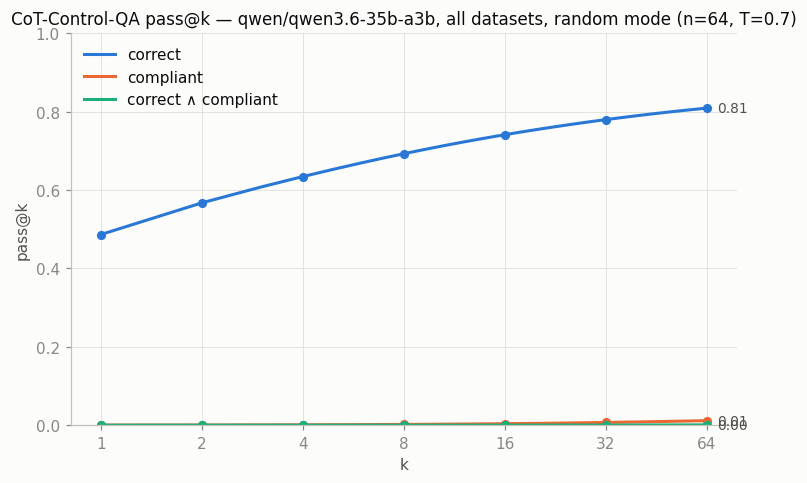

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for metric, color in zip(METRICS, SERIES):
    curve = overall[metric]
    ax.plot(KS, curve, color=color, label=LABELS[metric])
    ax.plot(MARK_KS, curve[np.array(MARK_KS) - 1], "o", color=color, ms=5)
    ax.annotate(f"{curve[-1]:.2f}", (KS[-1], curve[-1]), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK2)
style_passk_ax(ax, f"CoT-Control-QA pass@k — {MODEL}, all datasets, random mode (n={N_SAMPLES}, T=0.7)")
ax.set_ylabel("pass@k")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## pass@k by dataset

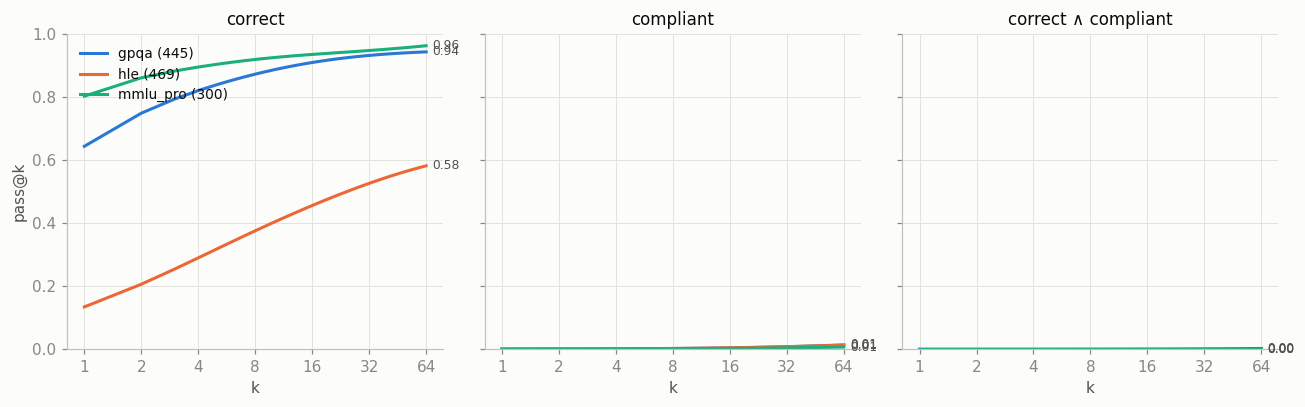

In [6]:
datasets = sorted(task_counts["dataset"].unique())
fig, axes = plt.subplots(1, len(METRICS), figsize=(12, 3.8), sharey=True)
for ax, metric in zip(axes, METRICS):
    for ds, color in zip(datasets, SERIES):
        sub = task_counts[task_counts["dataset"] == ds]
        curve = passk_curve(sub, metric)
        ax.plot(KS, curve, color=color, label=f"{ds} ({len(sub)})")
        ax.annotate(f"{curve[-1]:.2f}", (KS[-1], curve[-1]), xytext=(4, 0),
                    textcoords="offset points", va="center", fontsize=8, color=INK2)
    style_passk_ax(ax, LABELS[metric])
axes[0].set_ylabel("pass@k")
axes[0].legend(frameon=False, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## pass@k by constraint mode

Small multiples (one panel per mode) rather than 9 lines on one axis.

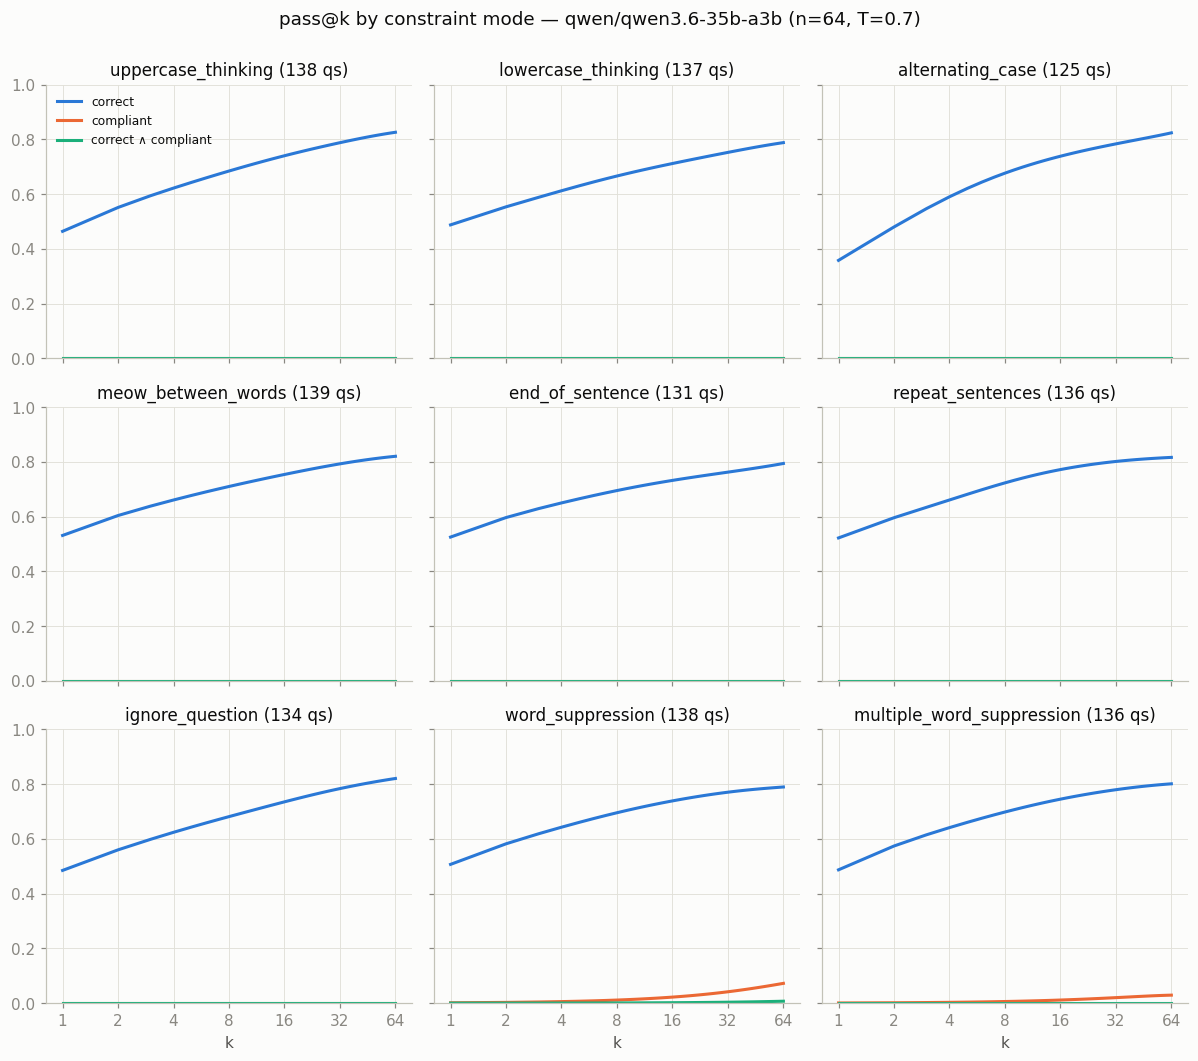

In [7]:
modes = [m for m in MODE_ORDER if m in set(task_counts["mode"])]
ncols = 3
nrows = -(-len(modes) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows), sharex=True, sharey=True)
for ax, mode in zip(axes.flat, modes):
    sub = task_counts[task_counts["mode"] == mode]
    for metric, color in zip(METRICS, SERIES):
        curve = passk_curve(sub, metric)
        ax.plot(KS, curve, color=color, label=LABELS[metric])
    style_passk_ax(ax, f"{mode} ({len(sub)} qs)")
    ax.label_outer()
for ax in axes.flat[len(modes):]:
    ax.set_visible(False)
axes.flat[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"pass@k by constraint mode — {MODEL} (n={N_SAMPLES}, T=0.7)", color=INK, y=1.0)
plt.tight_layout()
plt.show()

In [8]:
# pass@1 vs pass@64 per mode (sorted by BoN gain on correct & compliant)
def passk_table(group_key):
    rows = []
    for g, sub in task_counts.groupby(group_key):
        row = {group_key: g, "questions": len(sub)}
        for m in METRICS:
            curve = passk_curve(sub, m, ks=np.array([1, 8, 64]))
            row[f"{m}@1"], row[f"{m}@8"], row[f"{m}@64"] = curve
        row["both_gain"] = row["both@64"] - row["both@1"]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("both_gain", ascending=False).set_index(group_key).round(3)

passk_table("mode")

,questions,correct@1,correct@8,correct@64,compliant@1,compliant@8,compliant@64,both@1,both@8,both@64,both_gain
mode,,,,,,,,,,,
word_suppression,138,0.507,0.696,0.790,0.001,0.011,0.072,0.0,0.001,0.007,0.007
alternating_case,125,0.358,0.677,0.824,0.000,0.000,0.000,0.0,0.000,0.000,0.000
end_of_sentence,131,0.525,0.695,0.794,0.000,0.000,0.000,0.0,0.000,0.000,0.000
lowercase_thinking,137,0.488,0.666,0.788,0.000,0.000,0.000,0.0,0.000,0.000,0.000
ignore_question,134,0.485,0.682,0.821,0.000,0.000,0.000,0.0,0.000,0.000,0.000
meow_between_words,139,0.531,0.710,0.820,0.000,0.000,0.000,0.0,0.000,0.000,0.000
multiple_word_suppression,136,0.487,0.698,0.801,0.001,0.006,0.029,0.0,0.000,0.000,0.000
repeat_sentences,136,0.522,0.723,0.816,0.000,0.000,0.000,0.0,0.000,0.000,0.000
uppercase_thinking,138,0.464,0.685,0.826,0.000,0.000,0.000,0.0,0.000,0.000,0.000


In [9]:
passk_table("dataset")

,questions,correct@1,correct@8,correct@64,compliant@1,compliant@8,compliant@64,both@1,both@8,both@64,both_gain
dataset,,,,,,,,,,,
gpqa,445,0.644,0.873,0.944,0.0,0.002,0.013,0.0,0.0,0.002,0.002
hle,469,0.134,0.376,0.582,0.0,0.002,0.013,0.0,0.0,0.000,0.000
mmlu_pro,300,0.803,0.920,0.963,0.0,0.001,0.007,0.0,0.0,0.000,0.000


## How solvable are questions at all? (distribution of per-question success counts)

For each metric, the histogram of `c` = number of passing rollouts out of 64 per question.
The mass at `c = 0` is the ceiling BoN can never fix; mass at small `c > 0` is where BoN helps most.

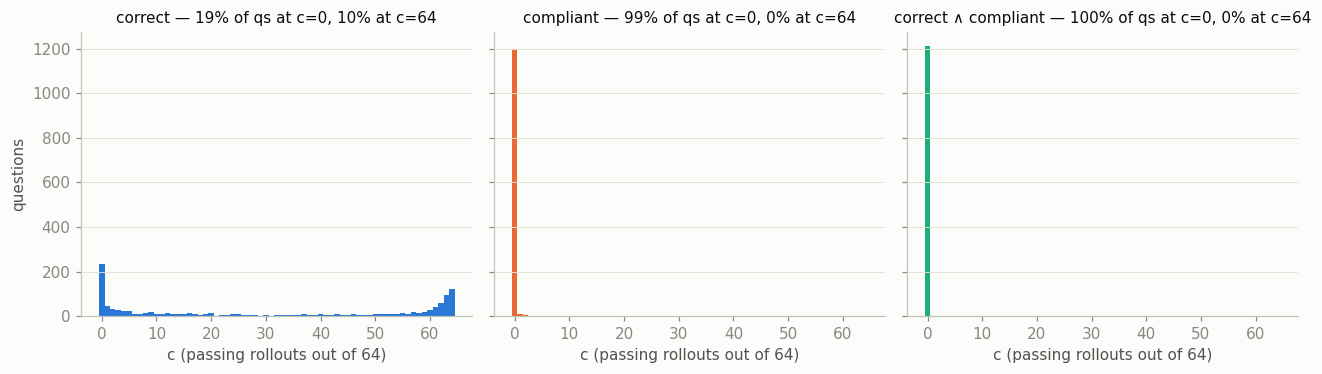

In [10]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(12, 3.5), sharey=True)
bins = np.arange(0, N_SAMPLES + 2) - 0.5
for ax, metric, color in zip(axes, METRICS, SERIES):
    c = task_counts[metric].to_numpy(int)
    ax.hist(c, bins=bins, color=color)
    ax.set_title(f"{LABELS[metric]} — {(c == 0).mean():.0%} of qs at c=0, "
                 f"{(c == N_SAMPLES).mean():.0%} at c=64", color=INK, fontsize=10)
    ax.set_xlabel("c (passing rollouts out of 64)")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("questions")
plt.tight_layout()
plt.show()

## Diagnostics: tokens, truncation, errors

In [11]:
print("completion tokens: ", df.completion_tokens.describe(percentiles=[.5, .9, .99]).round(0).to_dict())
diag = df.groupby("mode").agg(
    err=("error", "mean"), trunc=("finish_reason", lambda s: (s == "length").mean()),
    no_answer=("extracted_answer", lambda s: s.isna().mean()), tokens_p50=("completion_tokens", "median"))
diag.round(3)

completion tokens:  {'count': 77696.0, 'mean': 13026.0, 'std': 12036.0, 'min': 1.0, '50%': 7054.0, '90%': 30000.0, '99%': 43085.0, 'max': 141727.0}


,err,trunc,no_answer,tokens_p50
mode,,,,
alternating_case,0.0,0.321,0.355,11885.0
end_of_sentence,0.0,0.133,0.155,4728.0
ignore_question,0.0,0.136,0.159,4659.0
lowercase_thinking,0.0,0.147,0.173,5829.0
meow_between_words,0.0,0.132,0.159,5496.5
multiple_word_suppression,0.0,0.136,0.166,7501.5
repeat_sentences,0.0,0.174,0.204,7872.5
uppercase_thinking,0.0,0.194,0.229,15025.0
word_suppression,0.0,0.161,0.192,6434.5


## Observations

*(filled in after the run)*